1.What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning? 
Ans->**Deep Learning** is a subfield of Machine Learning that focuses on using artificial neural networks with multiple layers to learn complex patterns from data automatically. It is based on the idea of hierarchical learning, where each layer extracts higher-level features from the previous one. This makes deep learning highly effective for tasks such as image recognition, speech processing, and natural language understanding.

The evolution of deep learning began with early neural network concepts in the 1940s and 1950s, followed by the development of the perceptron by Frank Rosenblatt. However, due to limitations in solving non-linear problems, research slowed down for some time. The field revived in the 1980s with the introduction of backpropagation, significantly advanced by Geoffrey Hinton and others, allowing multi-layer networks to be trained effectively. In the 2000s and especially after 2010, the availability of large datasets and powerful GPUs led to major breakthroughs, making deep learning widely used in real-world applications.

Deep learning differs from traditional machine learning in several ways. In traditional machine learning, feature extraction is done manually by experts, while deep learning automatically learns features from raw data. Traditional models are usually shallow and simpler, whereas deep learning models are deeper and more complex, enabling them to capture highly non-linear relationships. Additionally, traditional machine learning works well with smaller datasets, while deep learning typically requires large amounts of data for better performance. Overall, deep learning provides more accurate results for complex problems but at the cost of higher computational requirements.

2.Explain the basic architecture and functioning of a Perceptron. What are its limitations?
Ans->
A Perceptron is one of the simplest types of artificial neural networks and is used for binary classification tasks. It consists of an input layer and an output layer, where each input is associated with a weight. The perceptron computes a weighted sum of the input features and adds a bias term. This result is then passed through an activation function, typically a step function, to produce the final output.
The basic architecture of a perceptron includes input nodes, weights, a bias, a summation unit, and an activation function. Mathematically, it can be represented as a linear combination of inputs and weights. The perceptron learns by adjusting its weights using a learning rule based on the error between the predicted output and the actual output. If the prediction is incorrect, the weights are updated to reduce the error, allowing the model to improve over time.
The functioning of a perceptron involves taking input values, multiplying them by their respective weights, summing them along with the bias, and then passing the result through an activation function to generate an output. This output is then compared with the actual label, and weights are updated accordingly using a simple update rule. This process is repeated over multiple iterations until the model converges.
However, the perceptron has several limitations. It can only solve linearly separable problems and fails to classify data that is not linearly separable, such as the XOR problem. It also uses a hard threshold activation function, which limits its ability to learn complex patterns. Additionally, it does not support multi-class classification directly and lacks the capability to model complex relationships in data, which is why more advanced neural network architectures are used in practice.

3.Describe the purpose of activation function in neural networks. Compare Sigmoid, ReLU, and Tanh functions?
Ans->
An activation function in a neural network is used to introduce non-linearity into the model. Without activation functions, a neural network would behave like a simple linear model, regardless of the number of layers. Activation functions help the network learn complex patterns and relationships in the data by transforming the input signal into an output signal that can be used by the next layer.
The purpose of an activation function is to determine whether a neuron should be activated or not based on the weighted sum of inputs. It also helps in controlling the output of a neuron and enables the network to approximate non-linear functions. This makes neural networks powerful for solving real-world problems such as classification and regression.
The Sigmoid function maps input values into a range between 0 and 1, making it useful for binary classification problems. However, it suffers from the vanishing gradient problem, where gradients become very small for large input values, slowing down learning.
The ReLU (Rectified Linear Unit) function outputs zero for negative inputs and the input itself for positive values. It is computationally efficient and helps reduce the vanishing gradient problem, making it widely used in deep learning models. However, it can suffer from the “dying ReLU” problem, where neurons stop learning if they output zero consistently.
The Tanh (Hyperbolic Tangent) function maps input values between -1 and 1. It is similar to the sigmoid function but is zero-centered, which often leads to faster convergence during training. However, like sigmoid, it also suffers from the vanishing gradient problem for very large or very small input values.
In comparison, Sigmoid is useful for probability outputs but is slow to train, ReLU is fast and efficient and commonly used in hidden layers, while Tanh provides better normalization but still faces gradient issues.

4.What is the difference between Loss function and Cost function in neural networks? Provide examples.
Ans->
In neural networks, loss function and cost function are related concepts used to measure the error between predicted values and actual values, but they differ slightly in scope.
A loss function calculates the error for a single training example. It measures how well the model’s prediction matches the actual output for one data point. Examples of loss functions include Mean Squared Error (MSE) for regression tasks and Binary Cross-Entropy for binary classification.
A cost function, on the other hand, is the average of the loss function over the entire training dataset. It represents the overall performance of the model across all training examples. The goal of training a neural network is to minimize the cost function.
For example, in regression problems, Mean Squared Error can act as both a loss function (for one sample) and a cost function (when averaged over all samples). In classification problems, Cross-Entropy Loss is commonly used to measure the difference between predicted probabilities and actual class labels.
In summary, the loss function is calculated for individual data points, while the cost function is the aggregated value used to evaluate and optimize the entire model.

5.What is the role of optimizers in neural networks? Compare Gradient Descent, Adam, and RMSprop?
Ans->
Optimizers in neural networks are algorithms used to adjust the weights and biases of the model in order to minimize the cost function. They play a crucial role in training by determining how the model learns from the data and how quickly it converges to an optimal solution.
The main function of an optimizer is to update the model parameters based on the gradients computed during backpropagation. A good optimizer helps the model reach the minimum error efficiently and improves overall performance.
Gradient Descent is the simplest optimization algorithm. It updates the weights in the direction of the negative gradient of the loss function. While it is easy to understand and implement, it can be slow and may get stuck in local minima.
RMSprop is an improvement over basic gradient descent. It adapts the learning rate for each parameter by dividing the gradient by a moving average of squared gradients. This helps in faster convergence and better handling of non-stationary problems.
Adam (Adaptive Moment Estimation) combines the advantages of both Momentum and RMSprop. It maintains moving averages of both gradients and squared gradients, allowing it to adapt the learning rate efficiently. Adam is widely used because it converges faster and performs well in most deep learning tasks.
In comparison, Gradient Descent is simple but slow, RMSprop improves convergence by adapting learning rates, and Adam is the most efficient and widely used optimizer due to its adaptive and faster learning capabilities.

In [1]:
#6.Write a Python program to implement a single-layer perceptron from scratch using NumPy to solve the logical AND gate.
import numpy as np

# Step activation function
def step_function(x):
    return np.where(x >= 0, 1, 0)

# Perceptron class
class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=10):
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        n_features = X.shape[1]
        
        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Training
        for _ in range(self.epochs):
            for i in range(len(X)):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = step_function(linear_output)

                # Update rule
                update = self.lr * (y[i] - y_pred)
                self.weights += update * X[i]
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return step_function(linear_output)


# AND gate dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])

# Train perceptron
model = Perceptron(learning_rate=0.1, epochs=10)
model.fit(X, y)

# Predictions
predictions = model.predict(X)

print("Predictions:", predictions)
print("Actual:", y)
print("Weights:", model.weights)
print("Bias:", model.bias)

Predictions: [0 0 0 1]
Actual: [0 0 0 1]
Weights: [0.2 0.1]
Bias: -0.20000000000000004


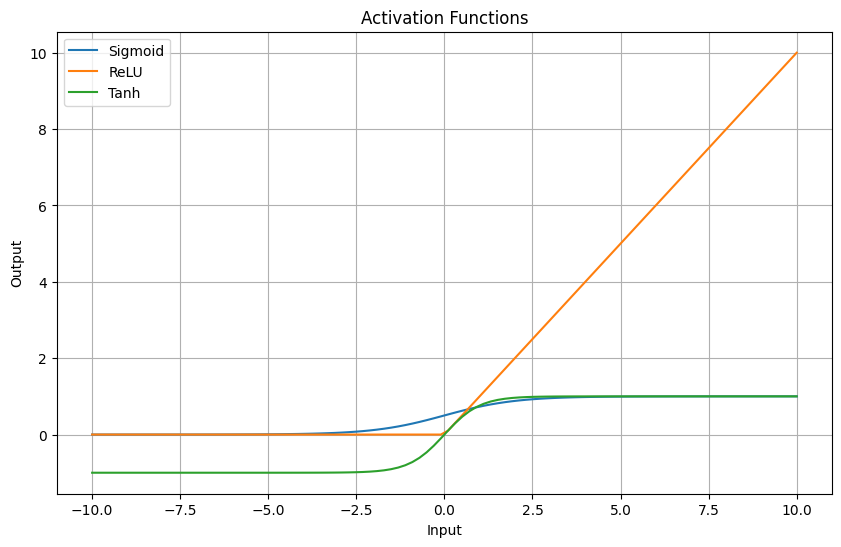

In [2]:
#7.Implement and visualize Sigmoid, ReLU, and Tanh activation functions using Matplotlib. 
import numpy as np
import matplotlib.pyplot as plt

# Define activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

# Generate input values
x = np.linspace(-10, 10, 100)

# Compute outputs
y_sigmoid = sigmoid(x)
y_relu = relu(x)
y_tanh = tanh(x)

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(x, y_sigmoid, label="Sigmoid")
plt.plot(x, y_relu, label="ReLU")
plt.plot(x, y_tanh, label="Tanh")

# Add details
plt.title("Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid()

plt.show()

In [4]:
#8.Use Keras to build and train a simple multilayer neural network on the MNIST digits dataset. Print the training accuracy.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten 28x28 images → 784 vector
X_train = X_train.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

# Build model
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes (digits 0–9)
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)

# Print final training accuracy
train_accuracy = history.history['accuracy'][-1]
print(f"Final Training Accuracy: {train_accuracy:.4f}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 13s 1us/step


C:\Users\ABINASH SAHANI\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9290 - loss: 0.2406
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9696 - loss: 0.1001
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9778 - loss: 0.0700
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9829 - loss: 0.0534
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9863 - loss: 0.0421
Final Training Accuracy: 0.9863


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8181 - loss: 0.5149 - val_accuracy: 0.8558 - val_loss: 0.4119
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8622 - loss: 0.3781 - val_accuracy: 0.8471 - val_loss: 0.4055
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8737 - loss: 0.3422 - val_accuracy: 0.8689 - val_loss: 0.3581
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8823 - loss: 0.3166 - val_accuracy: 0.8755 - val_loss: 0.3397
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8885 - loss: 0.3007 - val_accuracy: 0.8783 - val_loss: 0.3311
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8945 - loss: 0.2832 - val_accuracy: 0.8859 - val_loss: 0.3238
Epoch 7/10
1500/1500 ━━━━━━━━━━━

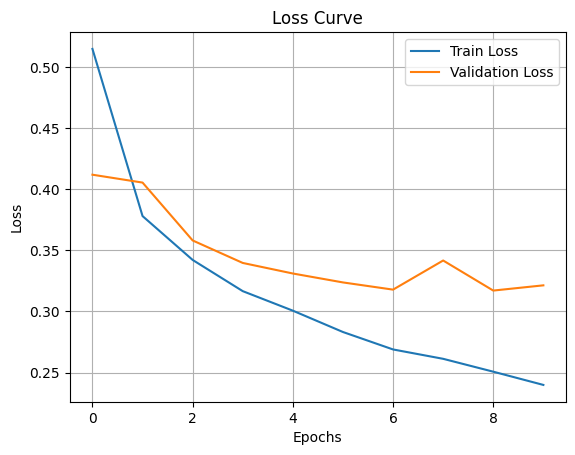

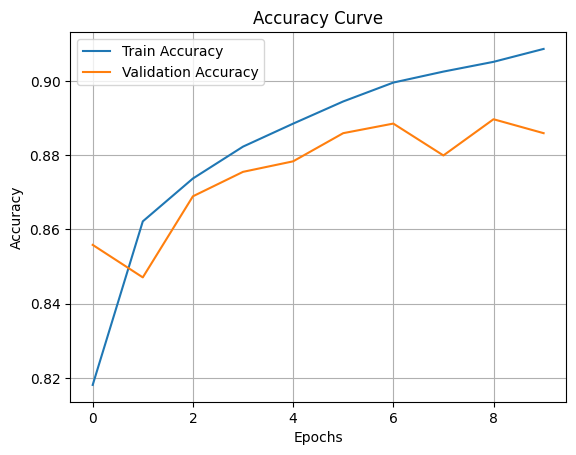

In [5]:
#9.Visualize the loss and accuracy curves for a neural network model trained on the Fashion MNIST dataset. Interpret the training behavior.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Load dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

# Build model
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train (with validation split)
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()

# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

In [6]:
#10. You are working on a project for a bank that wants to automatically detect fraudulent transactions. The dataset is large, imbalanced, and contains structured features like transaction amount, merchant ID, and customer location. The goal is to classify each transaction as fraudulent or legitimate. Explain your real-time data science workflow: ● How would you design a deep learning model (perceptron or multilayer NN)? ● Which activation function and loss function would you use, and why? ● How would you train and evaluate the model, considering class imbalance? ● Which optimizer would be suitable, and how would you prevent overfitting? 
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

# -----------------------------
# 1. Simulated dataset (replace with real data)
# -----------------------------
# Features: amount, merchant_id (encoded), location (encoded)
np.random.seed(42)

X = np.random.rand(10000, 10)   # 10 features
y = np.zeros(10000)

# Make imbalanced dataset (1% fraud)
y[:100] = 1  

# Shuffle
indices = np.random.permutation(len(X))
X, y = X[indices], y[indices]

# -----------------------------
# 2. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 3. Feature scaling
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# 4. Handle class imbalance
# -----------------------------
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {0: weights[0], 1: weights[1]}

print("Class Weights:", class_weights)

# -----------------------------
# 5. Build model
# -----------------------------
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# -----------------------------
# 6. Compile
# -----------------------------
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(),
        keras.metrics.Recall(),
        keras.metrics.AUC(name='auc')
    ]
)

# -----------------------------
# 7. Train
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)

# -----------------------------
# 8. Evaluate
# -----------------------------
results = model.evaluate(X_test, y_test, verbose=0)

print("\nTest Results:")
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

Class Weights: {0: np.float64(0.5047318611987381), 1: np.float64(53.333333333333336)}
Epoch 1/10


C:\Users\ABINASH SAHANI\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7873 - auc: 0.4591 - loss: 0.7425 - precision: 0.0083 - recall: 0.1803 - val_accuracy: 0.7350 - val_auc: 0.4847 - val_loss: 0.6299 - val_precision: 0.0096 - val_recall: 0.2857
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5830 - auc: 0.5761 - loss: 0.6910 - precision: 0.0123 - recall: 0.5410 - val_accuracy: 0.6606 - val_auc: 0.5335 - val_loss: 0.6421 - val_precision: 0.0129 - val_recall: 0.5000
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6445 - auc: 0.5935 - loss: 0.6886 - precision: 0.0132 - recall: 0.4918 - val_accuracy: 0.6769 - val_auc: 0.5124 - val_loss: 0.6257 - val_precision: 0.0078 - val_recall: 0.2857
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6669 - auc: 0.6395 - loss: 0.6735 - precision: 0.0163 - recall: 0.5738 - val_accuracy: 0.4319 - val_auc: 0.5393 - val_loss: 0.7202 - val_precision: 0.0088 - val_recall: 0.5714
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 